In [1]:
# ДЗ
# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.


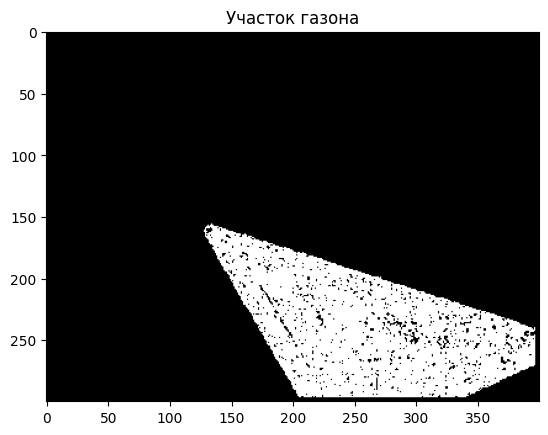

In [1]:
# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import copy
image = cv2.imread('sar_11.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])                                       
    if abs(av_val - img[point]) <= T:
        return True
    return False
def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i, j] == 0 and mask[i - r:i + r, j - r:j + r].sum() > 0:
                    if homo_fun(image, mask, (i, j), T):
                        local_mask[i, j] = 1
        count = np.count_nonzero(local_mask)
        mask += local_mask
    return mask * 255
seed_point = (250, 250)
r = 3
T = 15
mask = region_growing(image_gray, seed_point, homo_average, r, T)
plt.imshow(mask, cmap="gray")
plt.title("Участок газона")
plt.show()

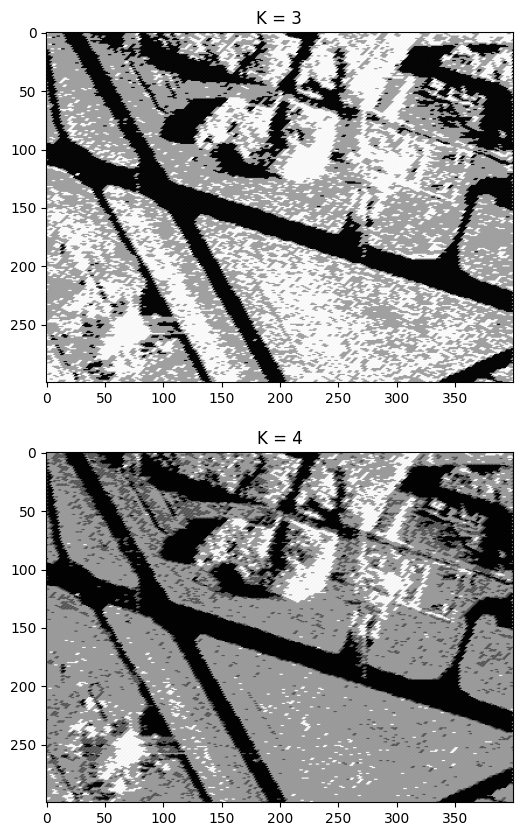

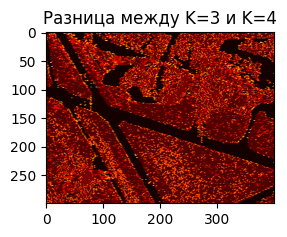

In [10]:
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
image = cv2.imread('sar_11.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
flags = cv2.KMEANS_RANDOM_CENTERS
z = image_gray.reshape((-1,3))
z = np.float32(z)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 5, 2.0)
K = 3
ret,label,center=cv2.kmeans(z,K,None,criteria,3,cv2.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((image_gray.shape))
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.imshow(res2, cmap="gray")
plt.title("K = 3")
K = 4
ret,label,center=cv2.kmeans(z,K,None,criteria,3,cv2.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((image_gray.shape))
plt.subplot(2, 1, 2)
plt.imshow(res2, cmap="gray")
plt.title("K = 4")
plt.show()
plt.figure(figsize=(10, 10))

# Пересчитаем для сравнения
K3_result = res2  # сохраним результат для K=3

K = 4
ret,label,center=cv2.kmeans(z,K,None,criteria,3,cv2.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
res = center[label.flatten()]
K4_result = res.reshape((image_gray.shape))

# Разница между кластеризациями
difference = np.abs(K3_result.astype(float) - K4_result.astype(float))
plt.subplot(1, 3, 3)
plt.imshow(difference, cmap="hot")
plt.title("Разница между K=3 и K=4")

plt.show()

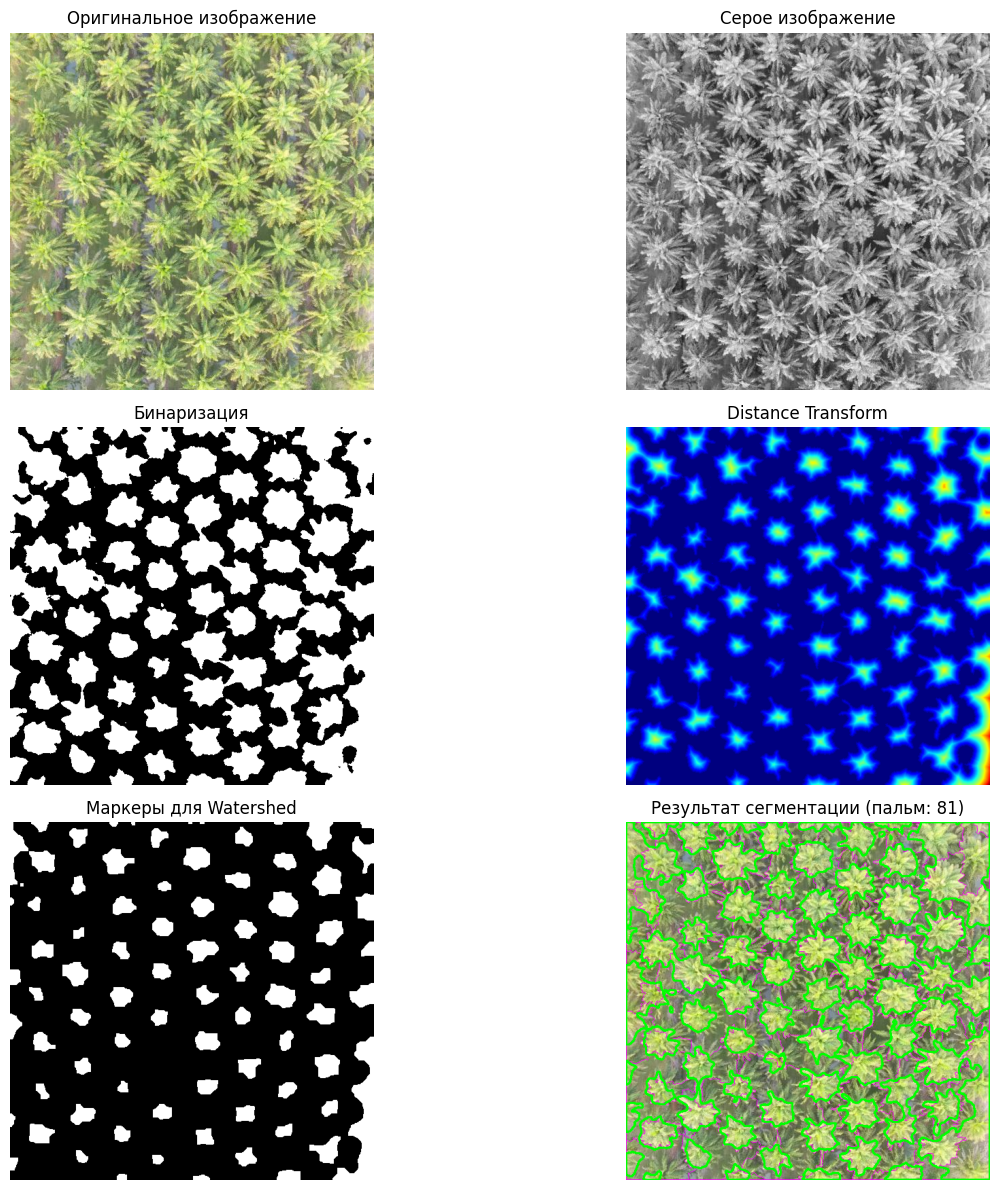

Количество пальм: 81


In [35]:
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.
from scipy import ndimage

# Загрузка и подготовка изображения
image = cv2.imread("palm_1.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Используем bilateralFilter для сохранения границ
blurred = cv2.bilateralFilter(gray, 15, 150, 150)

# Бинаризация - важно: пальмы должны быть белыми (255)
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Distance Transform
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)

# Создание маркеров для watershed с более низким порогом
ret, sure_fg = cv2.threshold(dist, 0.25 * dist.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)

# Морфологические операции для улучшения маркеров
kernel = np.ones((3, 3), np.uint8)
sure_fg = cv2.morphologyEx(sure_fg, cv2.MORPH_OPEN, kernel)
sure_fg = cv2.dilate(sure_fg, kernel, iterations=1)

# Connected Components и Watershed
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers.astype(np.int32)
markers = cv2.watershed(image_rgb, markers)

# Подсчет пальм (исключаем фон)
num_palms = ret - 1

# Создание изображения с результатами
result_image = image_rgb.copy()

# Отображение границ watershed
result_image[markers == -1] = [255, 0, 255]  # Фиолетовые границы

# Отображение контуров бинаризации
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(result_image, contours, -1, (0, 255, 0), 2)  # Зеленые контуры

# Визуализация
plt.figure(figsize=(15, 12))

plt.subplot(3, 2, 1)
plt.imshow(image_rgb)
plt.title("Оригинальное изображение")
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title("Серое изображение")
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(thresh, cmap='gray')
plt.title("Бинаризация")
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(dist, cmap='jet')
plt.title("Distance Transform")
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(sure_fg, cmap='gray')
plt.title("Маркеры для Watershed")
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(result_image)
plt.title(f"Результат сегментации (пальм: {num_palms})")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Количество пальм: {num_palms}")